# money

## UNDER CONSTRUCTION

I'm still working on this! Don't use it yet.

In [5]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('bmh')

In [6]:
# paths
DATA = Path.cwd().parent / "data"
MONEY = DATA / "prices/money.csv"

# plot kwargs
plotkw = {
    "figsize": (9, 3),
    "grid": True,
    "title": "exchange rate",
    "ylabel": "USD",
}


In [7]:
def clean_cols(data):
    return [x.lower().replace(' ', '_') for x in data.columns]

In [8]:
data = pd.read_csv(MONEY)
data.columns = clean_cols(data)
data['date'] = pd.to_datetime(data['date'])
data = (
    data
    .set_index(['date', 'country'])
    ['exchange_rate']
    .unstack('country')
    .sort_index()
    .sort_index(axis=1)
)
data.columns = clean_cols(data)
data.tail()

,australia,austria,belgium,brazil,canada,china,denmark,euro,finland,france,...,south_africa,south_korea,spain,sri_lanka,sweden,switzerland,taiwan,thailand,united_kingdom,venezuela
date,,,,,,,,,,,,,,,,,,,,,
2025-10-01,1.5274,NaN,NaN,5.3832,1.3988,7.1200,6.4155,0.8590,NaN,NaN,...,17.2722,1423.0795,NaN,303.0636,9.4253,0.7975,30.6032,32.5445,0.7487,201.1567
2025-11-01,1.5380,NaN,NaN,5.3415,1.4056,7.1069,6.4608,0.8652,NaN,NaN,...,17.2297,1459.8789,NaN,306.1411,9.5085,0.8037,31.1344,32.3700,0.7611,234.3391
2025-12-01,1.5053,NaN,NaN,5.4557,1.3795,7.0432,6.3784,0.8540,NaN,NaN,...,16.8327,1465.3550,NaN,309.1045,9.2935,0.7969,31.3523,31.5750,0.7470,271.1858
2026-01-01,1.4723,NaN,NaN,5.3316,1.3771,6.9692,6.3612,0.8515,NaN,NaN,...,16.2625,1455.4960,NaN,309.4585,9.0897,0.7894,31.5180,31.2750,0.7388,336.0177
2026-02-01,1.4164,NaN,NaN,5.1988,1.3648,6.9064,6.3176,0.8457,NaN,NaN,...,15.9937,1447.2858,NaN,309.2937,8.9888,0.7729,31.4705,31.2453,0.7364,391.6973


In [9]:
data.columns

Index(['australia', 'austria', 'belgium', 'brazil', 'canada', 'china',
       'denmark', 'euro', 'finland', 'france', 'germany', 'greece',
       'hong_kong', 'india', 'ireland', 'italy', 'japan', 'malaysia', 'mexico',
       'netherlands', 'new_zealand', 'norway', 'portugal', 'singapore',
       'south_africa', 'south_korea', 'spain', 'sri_lanka', 'sweden',
       'switzerland', 'taiwan', 'thailand', 'united_kingdom', 'venezuela'],
      dtype='str')

In [10]:
# Many European countries switched to EUR.
# Their exchange rates will be NaN after switching.
badrows = data.isnull().sum()
badrows.nlargest(10)

greece      425
euro        336
portugal    314
spain       314
austria     290
belgium     290
finland     290
france      290
germany     290
ireland     290
dtype: int64

<Axes: title={'center': 'exchange rate'}, xlabel='date', ylabel='USD'>

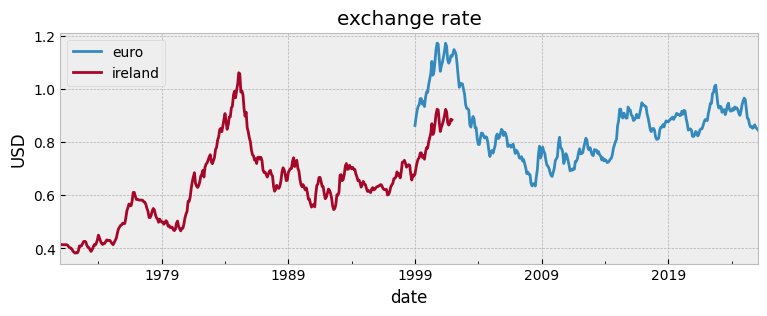

In [11]:
# Most of these rates are in units of 1 / USD.
# Some rates are in units of USD. This is confusing.
# Let's convert them all to USD.
# see https://github.com/datasets/exchange-rates/tree/main
flipped = [
    'euro',
    'ireland',
]
flipcols = sorted(set(data.columns) - set(flipped))
data[flipcols] = 1 / data[flipcols]
data[flipped].plot(**plotkw)

<Axes: title={'center': 'exchange rate'}, xlabel='date', ylabel='USD'>

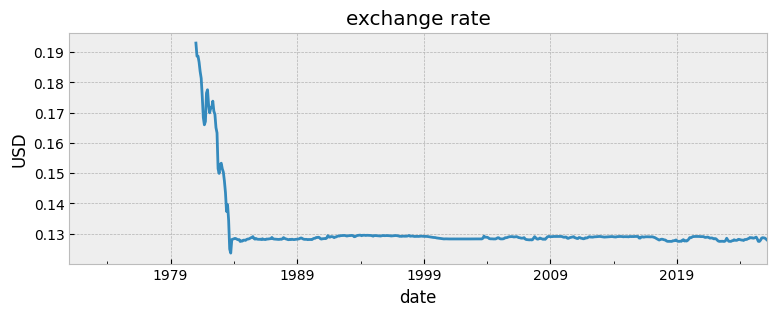

In [12]:
# Hong Kong has its own currency HKD (Hong Kong Dollar).
# In 1983-10-07, it was "pegged" at about 0.1282 USD.
# Since then, the hong_kong plot should be a flat line.
data['hong_kong'].plot(**plotkw)

<Axes: title={'center': 'exchange rate'}, xlabel='date', ylabel='USD'>

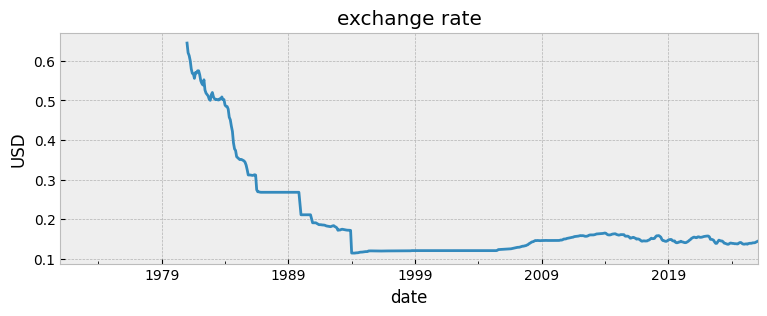

In [13]:
# 人民币 was "pegged" to about 0.115 USD from 1994 until 2005.
# Since then, it has "floated" in a narrow range
# based on a "basket" of other currencies.
data['china'].plot(**plotkw)

<Axes: title={'center': 'exchange rate'}, ylabel='USD'>

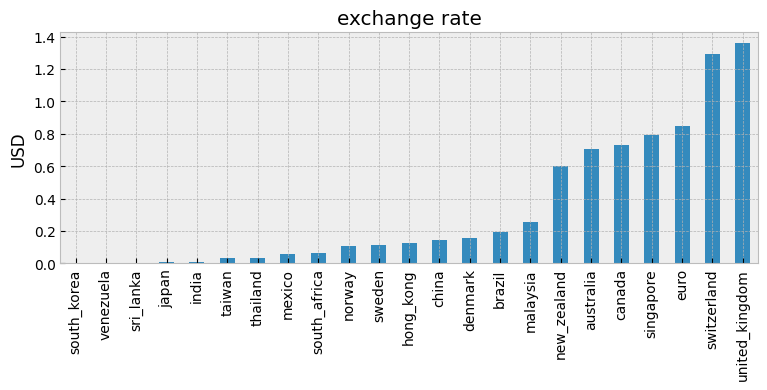

In [14]:
# Show the most recent not-null rates
(data
    .loc[data.index.max()]
    .dropna()
    .sort_values()
    .plot(**plotkw, kind='bar')
)